# GraphSentry — Research Notebook

Fraud detection on the Elliptic Bitcoin transaction network: classical graph analytics + a GraphSAGE GNN, benchmarked against XGBoost.

This notebook is a narrative walkthrough of the project's findings, reusing the exact same modules the rest of the codebase runs — nothing here is recomputed with different logic. Every number matches the README. For the full reasoning behind each design decision (why a temporal split, why these features were excluded, why the GNN was tuned the way it was), see the module docstrings referenced throughout and the README.


In [2]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False


## 1. The dataset

203,769 Bitcoin transactions (nodes), 234,355 directed edges, spanning 49 discrete time steps. Most nodes have no human-assigned label.


In [3]:
from data.loader import load_elliptic, sanity_check

dataset = load_elliptic()
report = sanity_check(dataset)
for k, v in report.items():
    print(f"{k:>28}: {v}")


                     n_nodes: 203769
                     n_edges: 234355
                n_time_steps: 49
             time_step_range: (1, 49)
                   n_illicit: 4545
                     n_licit: 42019
                   n_unknown: 157205
                 pct_unknown: 77.1
      pct_illicit_of_labeled: 9.8


### Class balance and illicit concentration over time

Illicit is a small minority throughout, but its rate isn't stable over time -- some time steps have far more illicit activity than others (real spikes tied to actual events, not noise).


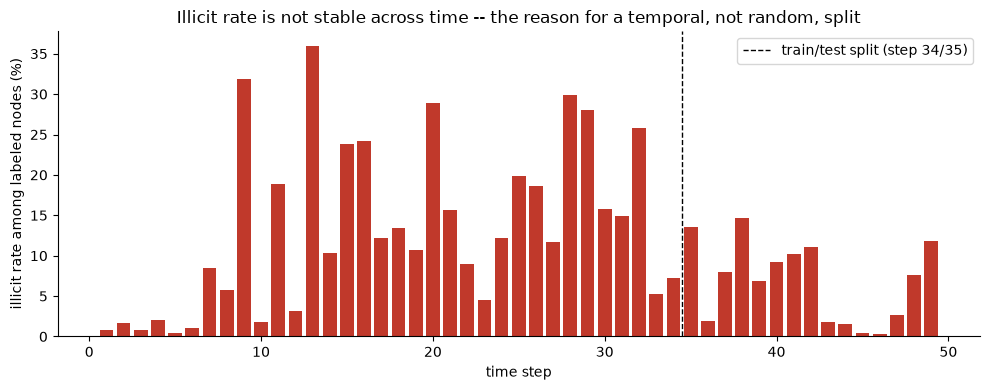

In [4]:
from features.build_features import build_feature_table

full_table = build_feature_table()
per_step = full_table.groupby("time_step")["label"].value_counts().unstack(fill_value=0)
per_step = per_step.rename(columns={1: "illicit", 0: "licit", -1: "unknown"})
per_step["illicit_rate"] = per_step["illicit"] / (per_step["illicit"] + per_step["licit"]).replace(0, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(per_step.index, per_step["illicit_rate"] * 100, color="#c0392b")
ax.axvline(34.5, color="black", linestyle="--", linewidth=1, label="train/test split (step 34/35)")
ax.set_xlabel("time step")
ax.set_ylabel("illicit rate among labeled nodes (%)")
ax.set_title("Illicit rate is not stable across time -- the reason for a temporal, not random, split")
ax.legend()
plt.tight_layout()
plt.show()


## 2. Graph structure: 49 disjoint components, not one connected mass

A finding that shapes everything downstream: verified directly (not assumed) that every edge connects two nodes within the *same* time step. There are zero edges crossing time steps -- so the graph is really 49 separate transaction subgraphs sitting side by side.


Number of weakly-connected components: 49
Largest component: 7880 nodes
Smallest component: 1089 nodes


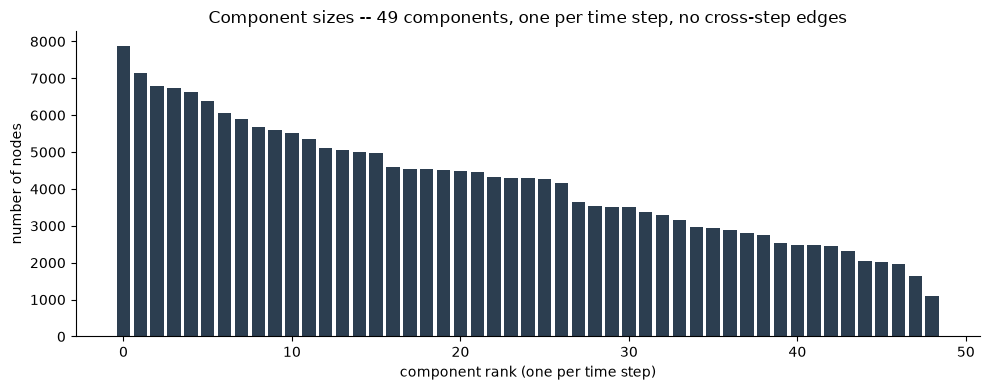

In [5]:
import pickle
import networkx as nx

with open("../graph/cache/graph.pkl", "rb") as f:
    graph = pickle.load(f)

components = list(nx.weakly_connected_components(graph))
sizes = sorted((len(c) for c in components), reverse=True)
print(f"Number of weakly-connected components: {len(components)}")
print(f"Largest component: {sizes[0]} nodes")
print(f"Smallest component: {sizes[-1]} nodes")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(sizes)), sizes, color="#2c3e50")
ax.set_xlabel("component rank (one per time step)")
ax.set_ylabel("number of nodes")
ax.set_title("Component sizes -- 49 components, one per time step, no cross-step edges")
plt.tight_layout()
plt.show()


## 3. Classical graph analytics: do illicit nodes cluster?

PageRank, degree, clustering coefficient, betweenness centrality, and Louvain community detection were computed on top of the graph (see `graph/analytics.py`). The key question: does illicit activity concentrate into specific communities, or spread evenly?


In [6]:
from graph.analytics import check_illicit_clustering

communities = full_table["community"].astype(int)
grouped = check_illicit_clustering(dataset, communities, verbose=True)


Baseline illicit rate among labeled nodes: 0.0976
Communities with labeled nodes >= 20: 112 of 315 total
Communities with illicit_rate > 2.0x baseline: 36
  -> hold 2064/4545 (45.4%) of all illicit nodes
  -> but only 27353/203769 (13.4%) of all nodes

Conclusion: illicit nodes cluster disproportionately into a minority of Louvain communities in this dataset.


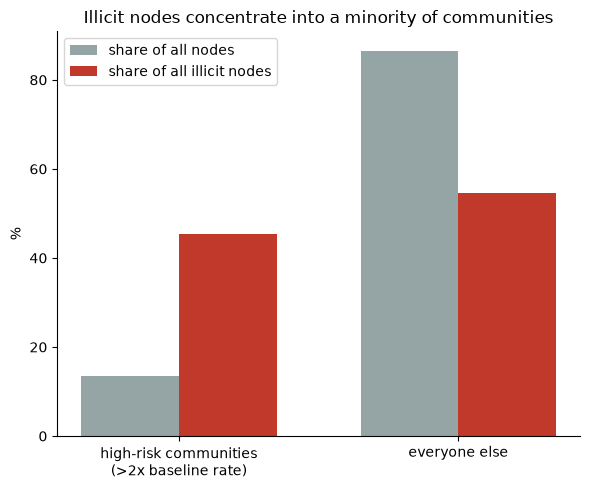

In [7]:
baseline_rate = dataset.nodes.loc[dataset.nodes["label"] >= 0, "label"].mean()
high_risk = grouped[grouped["illicit_rate"] > 2 * baseline_rate]

fig, ax = plt.subplots(figsize=(6, 5))
sizes_pie = [high_risk["size"].sum(), grouped["size"].sum() - high_risk["size"].sum()]
illicit_pie = [high_risk["illicit"].sum(), grouped["illicit"].sum() - high_risk["illicit"].sum()]

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [s / grouped["size"].sum() * 100 for s in sizes_pie], width, label="share of all nodes", color="#95a5a6")
ax.bar(x + width/2, [s / grouped["illicit"].sum() * 100 for s in illicit_pie], width, label="share of all illicit nodes", color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(["high-risk communities\n(>2x baseline rate)", "everyone else"])
ax.set_ylabel("%")
ax.set_title("Illicit nodes concentrate into a minority of communities")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Temporal train/test split

Steps 1-34 train, 35-49 test -- the convention from the original Elliptic paper. The illicit rate genuinely shifts between the two (already visible in the chart above), which is why this is evaluated as a real generalization problem, not glossed over with a random shuffle.


In [8]:
from features.build_features import get_labeled_subset, temporal_train_test_split, split_summary

labeled = get_labeled_subset(full_table)
train_df, test_df = temporal_train_test_split(labeled)
split_summary(train_df, test_df)


train: n=29894, illicit=3462 (11.6%), licit=26432, time_steps=(1, 34)
 test: n=16670, illicit=1083 (6.5%), licit=15587, time_steps=(35, 49)


## 5. Baseline: XGBoost

Full tuning history (regularization tried and rejected, recency weighting, the feature-drift audit that nearly doubled precision) is in `models/baseline_xgboost.py` and the README. This loads the final, cached model's predictions.


In [9]:
from models.compare_models import load_predictions, load_thresholds, compare
from features.build_features import DEFAULT_TRAIN_MAX_STEP

predictions = load_predictions()
xgb_threshold, gnn_threshold = load_thresholds()

test_predictions = predictions[predictions["time_step"] > DEFAULT_TRAIN_MAX_STEP]
comparison = compare("test", test_predictions, xgb_threshold, gnn_threshold)
comparison


,n,precision,recall,f1,pr_auc
model (test),,,,,
XGBoost,16670,0.953202,0.714681,0.816887,0.804399
GraphSAGE,16670,0.809140,0.555863,0.659004,0.631279


Top drivers of the final XGBoost model (see models/baseline_xgboost.py for the full feature-drift investigation that led to this feature set): feat_53, feat_41, feat_40, feat_163, feat_90 -- all raw Elliptic features that survived the drift audit; the 6 features with severe train/test distributional shift were excluded, which is what took precision from 0.537 to 0.953.

## 6. GraphSAGE GNN

Directed message passing (separate aggregation over in-neighbors and out-neighbors), trained under the identical temporal validation protocol as the baseline. Full investigation of why it underperforms -- diagnosed early stopping, a validation-only hyperparameter sweep, and two competing hypotheses about the gap (one refuted, one that held up in a more nuanced way than expected) -- is in `models/gnn_graphsage.py` and the README.


## 7. Final comparison: does the GNN beat the baseline?

**No.** Not on precision, not on recall, not on F1, not on PR-AUC, on the test set that actually matters. Stated plainly rather than tuned toward a different answer -- see the README's Results section for the full honest reasoning.


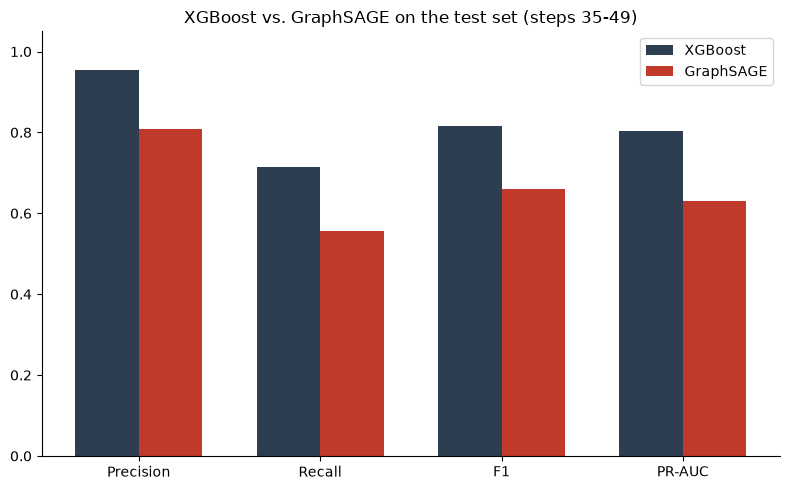


GNN does not beat the baseline on any of the four metrics.


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["precision", "recall", "f1", "pr_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.35

xgb_vals = comparison.loc["XGBoost", metrics_to_plot].to_numpy(dtype=float)
gnn_vals = comparison.loc["GraphSAGE", metrics_to_plot].to_numpy(dtype=float)

ax.bar(x - width/2, xgb_vals, width, label="XGBoost", color="#2c3e50")
ax.bar(x + width/2, gnn_vals, width, label="GraphSAGE", color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1", "PR-AUC"])
ax.set_ylim(0, 1.05)
ax.set_title("XGBoost vs. GraphSAGE on the test set (steps 35-49)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nGNN does not beat the baseline on any of the four metrics.")


## Conclusion

A feature-based baseline with good structural features (PageRank, community membership, degree, clustering coefficient) handed to it directly is a hard bar for a GNN to clear. That's the honest result here, and it matches a common finding in the graph-fraud literature rather than being a surprising one.

See the [README](../README.md) for the complete methodology, the full experimental history behind every number in this notebook, and documented limitations and future work.
